# 🗑️ Big Belly Smart Bins — Exploratory Data Analysis
## UC Berkeley Zero Waste Division

**Objective:** Analyze asset configuration and daily collection activity data to identify trends, inefficiencies, and features useful for building a predictive fill-rate forecasting model.

**Datasets:**
1. `Account_Assets_-_CLEAN.csv` — Inventory of all Big Belly smart bin units (location, stream type, GPS, thresholds)
2. `Daily_Collection_Activity_-_CLEAN.csv` — Single-day collection log (Feb 10, 2026) with fullness at pickup and collection reason

---

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("✅ Libraries loaded")


✅ Libraries loaded


In [3]:
# Load assets (skip metadata header rows)
assets = pd.read_csv('Account Assets - CLEAN.csv', skiprows=10)
assets.columns = assets.columns.str.strip().str.replace('"','')

# Load collection activity (skip metadata header rows)
collections = pd.read_csv('Daily Collection Activity - CLEAN.csv', skiprows=10)
collections.columns = collections.columns.str.strip().str.replace('"','')

print(f"Assets:      {assets.shape[0]} rows × {assets.shape[1]} columns")
print(f"Collections: {collections.shape[0]} rows × {collections.shape[1]} columns")


Assets:      251 rows × 13 columns
Collections: 73 rows × 8 columns


---
## 2. Asset Inventory Analysis
Understanding the fleet: how many bins, where they are, what streams they serve, and how they're configured.

In [4]:
assets.head(10)

,Description,Serial,Streams,Model ID,Capacity,Status,Fullness Threshold,Age Threshold,Last Called,Lat,Lng,Modem,Door Lock Type
0,001 Berkeley Way (Offsite),1514008,Compostables,SM5,Smart Max,In Service,60%,7 days,4 hours ago,37.873656,-122.267417,LE910,Manual Lock
1,001 Berkeley Way (Offsite),1514021,Bottles/Cans,SM5,Smart Max,In Service,60%,Disabled,8 hours ago,37.873643,-122.267404,ME910,Manual Lock
2,Bechtel East,1514004,Compostables,SM5,Smart Max,In Service,60%,7 days,6 hours ago,37.873929,-122.257781,LE910,Manual Lock
3,Bechtel East,1514018,Bottles/Cans,SM5,Smart Max,In Service,60%,7 days,7 hours ago,37.873929,-122.257781,LE910,Manual Lock
4,Bechtel East,1514027,Waste,SM5,Smart Max,In Service,60%,7 days,33 minutes ago,37.873929,-122.257781,LE910,Manual Lock
5,Bechtel West,1514006,Compostables,SM5,Smart Max,In Service,60%,7 days,4 hours ago,37.874197,-122.258726,LE910,Manual Lock
6,Bechtel West,1514012,Bottles/Cans,SM5,Smart Max,In Service,60%,7 days,9 hours ago,37.874197,-122.258726,LE910,Manual Lock
7,Bechtel West,1514024,Waste,SM5,Smart Max,In Service,60%,7 days,9 hours ago,37.874197,-122.258726,LE910,Manual Lock
8,Botanical Gardens,500101635,Compostables,SM5,Smart Max,In Service,60%,Disabled,11 hours ago,37.875414,-122.238996,ME910,Manual Lock
9,Botanical Gardens,500101630,Bottles/Cans,SM5,Smart Max,In Service,60%,Disabled,6 hours ago,37.875414,-122.238996,ME910,Manual Lock


In [5]:
assets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Description         251 non-null    object 
 1   Serial              251 non-null    int64  
 2   Streams             251 non-null    object 
 3   Model ID            251 non-null    object 
 4   Capacity            251 non-null    object 
 5   Status              251 non-null    object 
 6   Fullness Threshold  251 non-null    object 
 7   Age Threshold       251 non-null    object 
 8   Last Called         251 non-null    object 
 9   Lat                 251 non-null    float64
 10  Lng                 251 non-null    float64
 11  Modem               251 non-null    object 
 12  Door Lock Type      251 non-null    object 
dtypes: float64(2), int64(1), object(10)
memory usage: 25.6+ KB


In [6]:
# Clean up data types
assets['Lat'] = pd.to_numeric(assets['Lat'], errors='coerce')
assets['Lng'] = pd.to_numeric(assets['Lng'], errors='coerce')
assets['Fullness Threshold'] = assets['Fullness Threshold'].str.replace('%','').astype(float)

# Parse Age Threshold
def parse_age(val):
    val = str(val).strip()
    if 'day' in val.lower():
        try:
            return int(val.split()[0])
        except:
            return None
    return None

assets['Age Threshold Days'] = assets['Age Threshold'].apply(parse_age)

print(f"Total bin units: {len(assets)}")
print(f"Unique locations: {assets['Description'].nunique()}")
print(f"Unique serial numbers: {assets['Serial'].nunique()}")


Total bin units: 251
Unique locations: 91
Unique serial numbers: 251


### 2.1 Stream Type Distribution

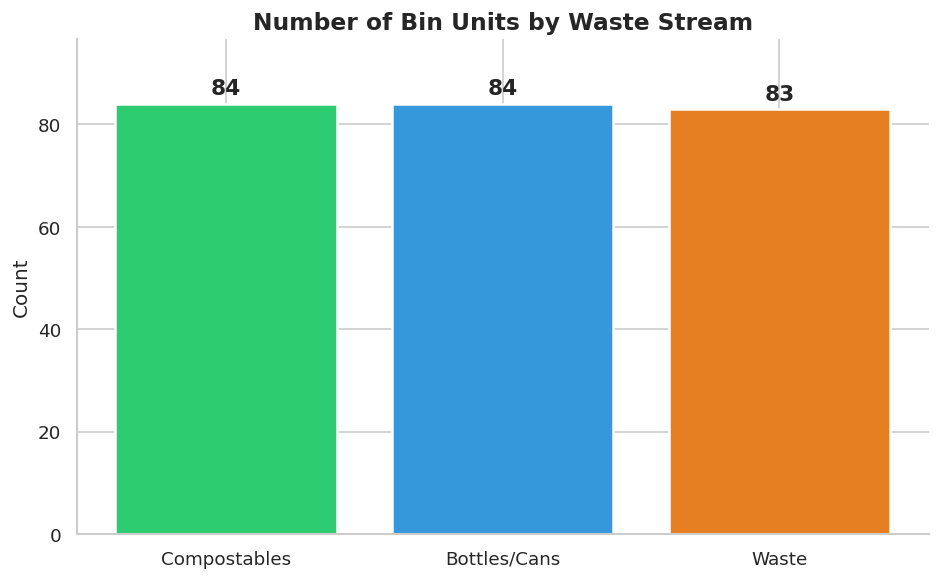

Streams
Compostables    84
Bottles/Cans    84
Waste           83


In [7]:
stream_counts = assets['Streams'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(stream_counts.index, stream_counts.values, 
              color=['#2ecc71', '#3498db', '#e67e22'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, stream_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val),
            ha='center', va='bottom', fontweight='bold', fontsize=13)
ax.set_title('Number of Bin Units by Waste Stream', fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, stream_counts.max() * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

print(stream_counts.to_string())


### 2.2 Bins Per Location

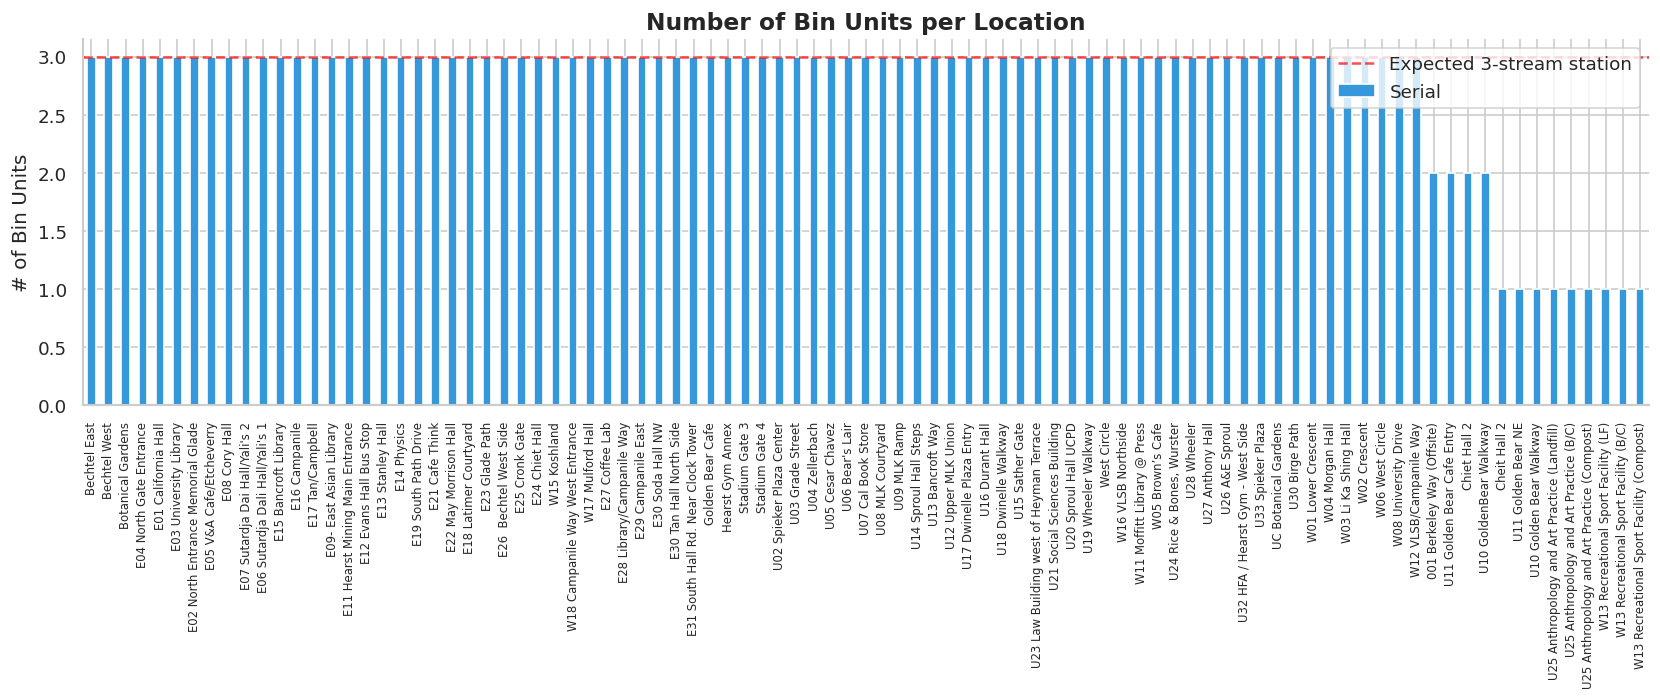


Locations with 3 streams (complete station): 78
Locations with < 3 streams (incomplete):     13
Locations with > 3 streams (multi-station):  0


In [8]:
bins_per_loc = assets.groupby('Description')['Serial'].count().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
bins_per_loc.plot(kind='bar', ax=ax, color='#3498db', edgecolor='white')
ax.set_title('Number of Bin Units per Location', fontweight='bold')
ax.set_ylabel('# of Bin Units')
ax.set_xlabel('')
ax.axhline(y=3, color='red', linestyle='--', alpha=0.7, label='Expected 3-stream station')
ax.legend()
plt.xticks(rotation=90, fontsize=7)
sns.despine()
plt.tight_layout()
plt.show()

print(f"\nLocations with 3 streams (complete station): {(bins_per_loc == 3).sum()}")
print(f"Locations with < 3 streams (incomplete):     {(bins_per_loc < 3).sum()}")
print(f"Locations with > 3 streams (multi-station):  {(bins_per_loc > 3).sum()}")


### 2.3 Status & Threshold Configuration

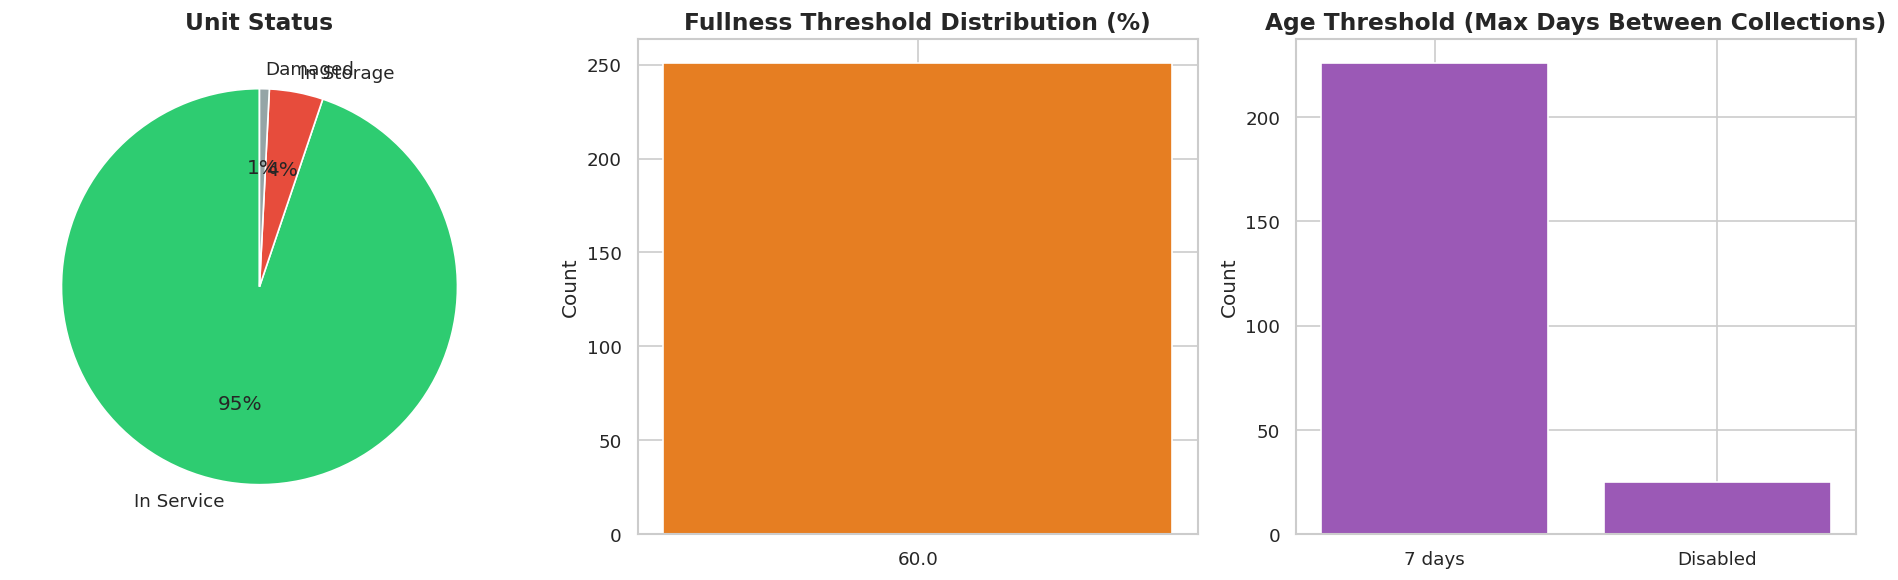


Age Threshold breakdown:
Age Threshold
7 days      226
Disabled     25


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Status
status_counts = assets['Status'].value_counts()
axes[0].pie(status_counts, labels=status_counts.index, autopct='%1.0f%%',
            colors=['#2ecc71', '#e74c3c', '#95a5a6'], startangle=90)
axes[0].set_title('Unit Status', fontweight='bold')

# Fullness Threshold
ft_counts = assets['Fullness Threshold'].value_counts().sort_index()
axes[1].bar(ft_counts.index.astype(str), ft_counts.values, color='#e67e22', edgecolor='white')
axes[1].set_title('Fullness Threshold Distribution (%)', fontweight='bold')
axes[1].set_ylabel('Count')

# Age Threshold
at_counts = assets['Age Threshold'].value_counts()
axes[2].bar(at_counts.index.astype(str), at_counts.values, color='#9b59b6', edgecolor='white')
axes[2].set_title('Age Threshold (Max Days Between Collections)', fontweight='bold')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("\nAge Threshold breakdown:")
print(at_counts.to_string())


### 2.4 Geographic Distribution

In [10]:
try:
    import folium
    from folium.plugins import MarkerCluster

    center_lat = assets['Lat'].mean()
    center_lng = assets['Lng'].mean()
    m = folium.Map(location=[center_lat, center_lng], zoom_start=15, tiles='CartoDB positron')

    stream_colors = {'Waste': 'red', 'Compostables': 'green', 'Bottles/Cans': 'blue'}
    
    for _, row in assets.iterrows():
        if pd.notna(row['Lat']) and pd.notna(row['Lng']):
            color = stream_colors.get(row['Streams'], 'gray')
            folium.CircleMarker(
                location=[row['Lat'], row['Lng']],
                radius=5, color=color, fill=True, fill_color=color, fill_opacity=0.7,
                popup=f"{row['Description']}<br>{row['Streams']}<br>Serial: {row['Serial']}"
            ).add_to(m)

    # Add legend
    legend_html = '''
    <div style="position:fixed; bottom:30px; left:30px; z-index:1000; 
                background:white; padding:10px; border-radius:5px; border:2px solid grey;">
    <b>Stream Type</b><br>
    <i style="color:red">●</i> Waste<br>
    <i style="color:green">●</i> Compostables<br>
    <i style="color:blue">●</i> Bottles/Cans
    </div>'''
    m.get_root().html.add_child(folium.Element(legend_html))

    display(m)
    print("✅ Interactive map rendered")
except Exception as e:
    # Fallback to matplotlib scatter
    fig, ax = plt.subplots(figsize=(10, 8))
    stream_colors = {'Waste': '#e74c3c', 'Compostables': '#2ecc71', 'Bottles/Cans': '#3498db'}
    for stream, color in stream_colors.items():
        mask = assets['Streams'] == stream
        ax.scatter(assets.loc[mask, 'Lng'], assets.loc[mask, 'Lat'], 
                   c=color, label=stream, alpha=0.7, s=40, edgecolors='white')
    ax.set_title('Big Belly Bin Locations — UC Berkeley', fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.legend(title='Stream')
    sns.despine()
    plt.tight_layout()
    plt.show()


✅ Interactive map rendered


---
## 3. Daily Collection Activity Analysis
Analyzing the single-day snapshot (Feb 10, 2026) of collection operations.

In [11]:
collections.head(10)

,Serial,Description,Capacity,Stream Type,Reason,Fullness Level at Collection,Collection Time,Note
0,1515688,W01 Lower Crescent,Smart Max,Compostables,Not Ready,0%,02/10/2026 04:43,-
1,1515755,U10 GoldenBear Walkway,Smart Max,Compostables,Fullness,60%,02/10/2026 04:49,-
2,500103012,Golden Bear Cafe,Smart Max,Compostables,Fullness,80%,02/10/2026 04:55,-
3,1514010,W05 Brown’s Cafe,Smart Max,Compostables,Fullness,80%,02/10/2026 04:56,-
4,1515790,U12 Upper MLK Union,Smart Max,Compostables,Fullness,60%,02/10/2026 04:59,-
5,1514032,W05 Brown’s Cafe,Smart Max,Waste,Fullness,60%,02/10/2026 05:03,-
6,1515719,W03 Li Ka Shing Hall,Smart Max,Compostables,Fullness,60%,02/10/2026 05:04,-
7,1515753,U08 MLK Courtyard,Smart Max,Compostables,Fullness,60%,02/10/2026 05:05,-
8,1515743,E02 North Entrance Memorial Glade,Smart Max,Waste,Not Ready,0%,02/10/2026 05:12,-
9,1515750,E02 North Entrance Memorial Glade,Smart Max,Compostables,Fullness,60%,02/10/2026 05:12,-


In [12]:
# Clean up
collections['Fullness Level at Collection'] = (
    collections['Fullness Level at Collection']
    .str.strip()
    .str.replace('%', '')
)

# Separate numeric fullness from alert strings
def parse_fullness(val):
    try:
        return float(val)
    except:
        return np.nan

collections['Fullness_Pct'] = collections['Fullness Level at Collection'].apply(parse_fullness)
collections['Collection Time'] = pd.to_datetime(collections['Collection Time'], errors='coerce')
collections['Hour'] = collections['Collection Time'].dt.hour

print(f"Total collections on Feb 10, 2026: {len(collections)}")
print(f"Unique bins serviced: {collections['Serial'].nunique()}")
print(f"Unique locations serviced: {collections['Description'].nunique()}")
print(f"\nCollection Reasons:")
print(collections['Reason'].value_counts().to_string())


Total collections on Feb 10, 2026: 73
Unique bins serviced: 63
Unique locations serviced: 47

Collection Reasons:
Reason
Fullness     55
Not Ready    16
Alert         2


### 3.1 Collection Reason Breakdown

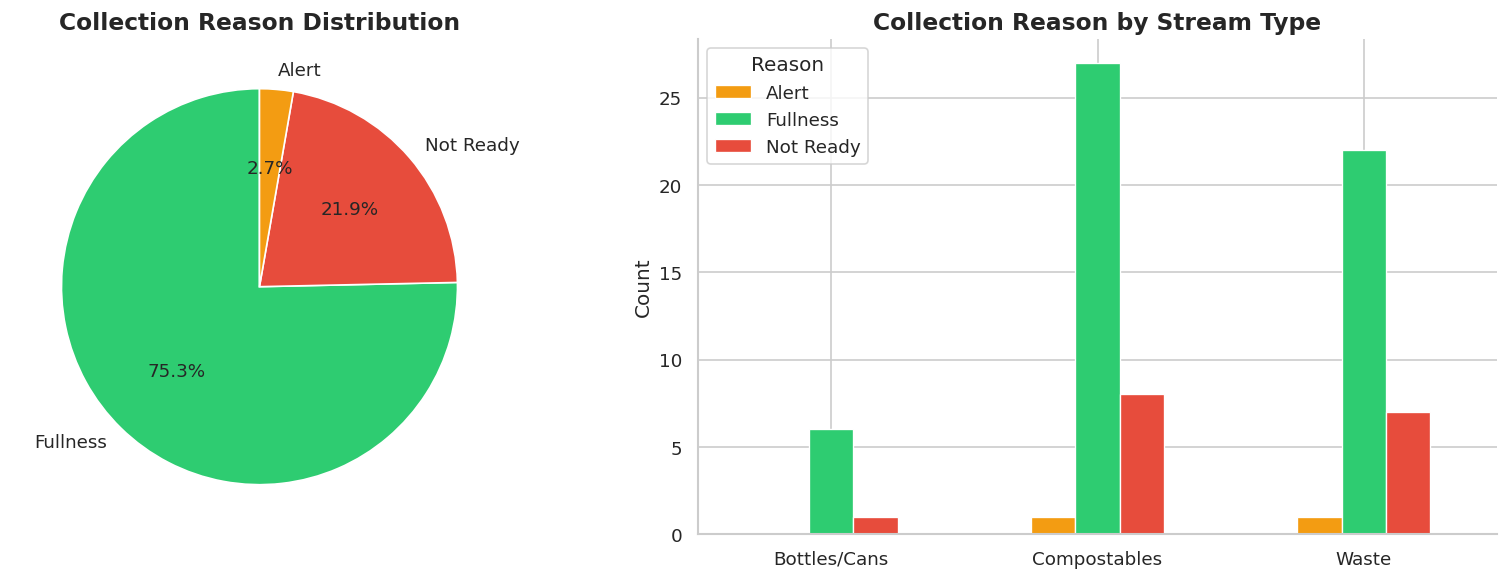

In [13]:
reason_counts = collections['Reason'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors_map = {'Fullness': '#2ecc71', 'Not Ready': '#e74c3c', 'Alert': '#f39c12'}
colors = [colors_map.get(r, '#95a5a6') for r in reason_counts.index]
axes[0].pie(reason_counts, labels=reason_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 11})
axes[0].set_title('Collection Reason Distribution', fontweight='bold')

# By stream
reason_stream = collections.groupby(['Stream Type', 'Reason']).size().unstack(fill_value=0)
reason_stream.plot(kind='bar', ax=axes[1], color=['#f39c12', '#2ecc71', '#e74c3c'], 
                   edgecolor='white', linewidth=0.8)
axes[1].set_title('Collection Reason by Stream Type', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('')
axes[1].legend(title='Reason')
plt.xticks(rotation=0)
sns.despine()
plt.tight_layout()
plt.show()


### 3.2 Fullness at Collection
This is a critical metric: bins collected at low fullness represent **wasted trips**, while bins at 100% may have already overflowed.

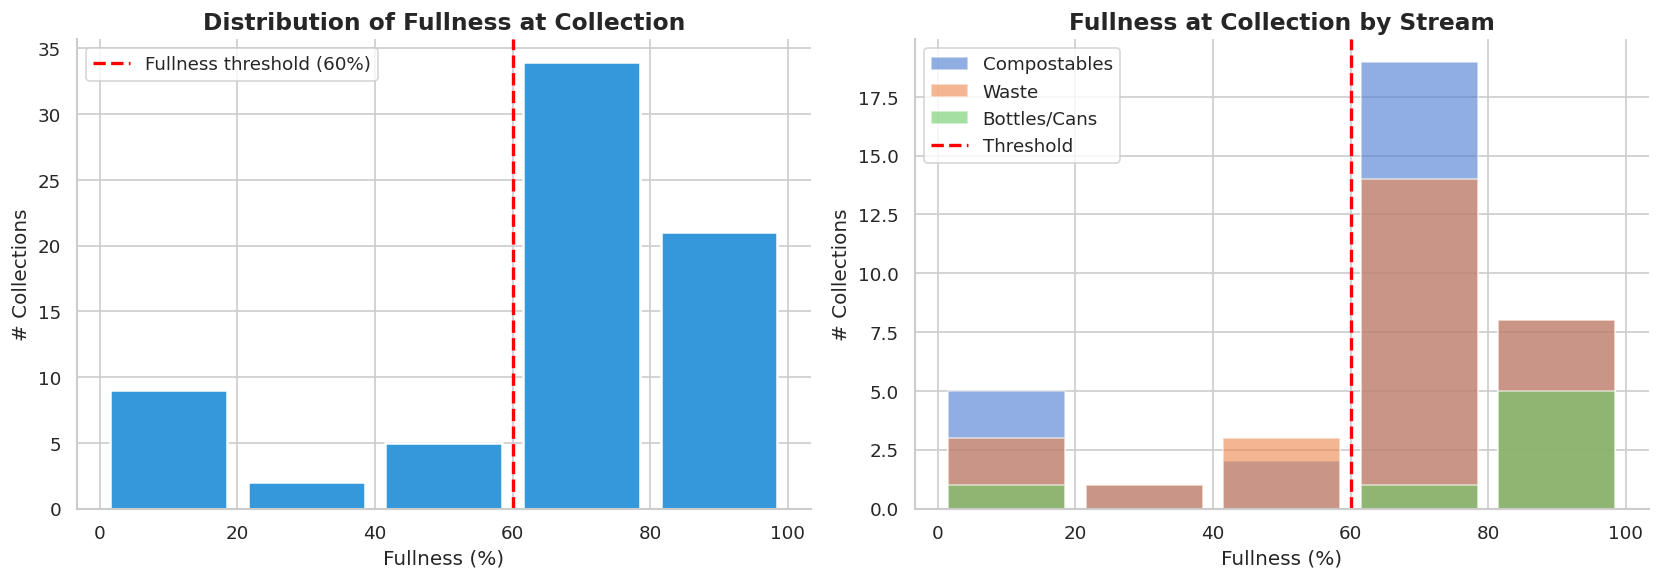


Fullness statistics:
count     71.000000
mean      56.619718
std       26.400415
min        0.000000
25%       60.000000
50%       60.000000
75%       80.000000
max      100.000000

Collections below threshold (< 60%): 16 / 71 (22.5%)
Collections at overflow (100%):       3 / 71 (4.2%)


In [14]:
# Filter to numeric fullness only
full_data = collections.dropna(subset=['Fullness_Pct'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(full_data['Fullness_Pct'], bins=[0, 20, 40, 60, 80, 100], 
             color='#3498db', edgecolor='white', linewidth=1.5, rwidth=0.85)
axes[0].axvline(x=60, color='red', linestyle='--', linewidth=2, label='Fullness threshold (60%)')
axes[0].set_title('Distribution of Fullness at Collection', fontweight='bold')
axes[0].set_xlabel('Fullness (%)')
axes[0].set_ylabel('# Collections')
axes[0].legend()

# By stream
for stream in full_data['Stream Type'].unique():
    subset = full_data[full_data['Stream Type'] == stream]['Fullness_Pct']
    axes[1].hist(subset, bins=[0, 20, 40, 60, 80, 100], alpha=0.6, label=stream, rwidth=0.85)
axes[1].axvline(x=60, color='red', linestyle='--', linewidth=2, label='Threshold')
axes[1].set_title('Fullness at Collection by Stream', fontweight='bold')
axes[1].set_xlabel('Fullness (%)')
axes[1].set_ylabel('# Collections')
axes[1].legend()
sns.despine()
plt.tight_layout()
plt.show()

print(f"\nFullness statistics:")
print(full_data['Fullness_Pct'].describe().to_string())
print(f"\nCollections below threshold (< 60%): {(full_data['Fullness_Pct'] < 60).sum()} / {len(full_data)} ({(full_data['Fullness_Pct'] < 60).mean()*100:.1f}%)")
print(f"Collections at overflow (100%):       {(full_data['Fullness_Pct'] >= 100).sum()} / {len(full_data)} ({(full_data['Fullness_Pct'] >= 100).mean()*100:.1f}%)")


### 3.3 Collection Efficiency Analysis

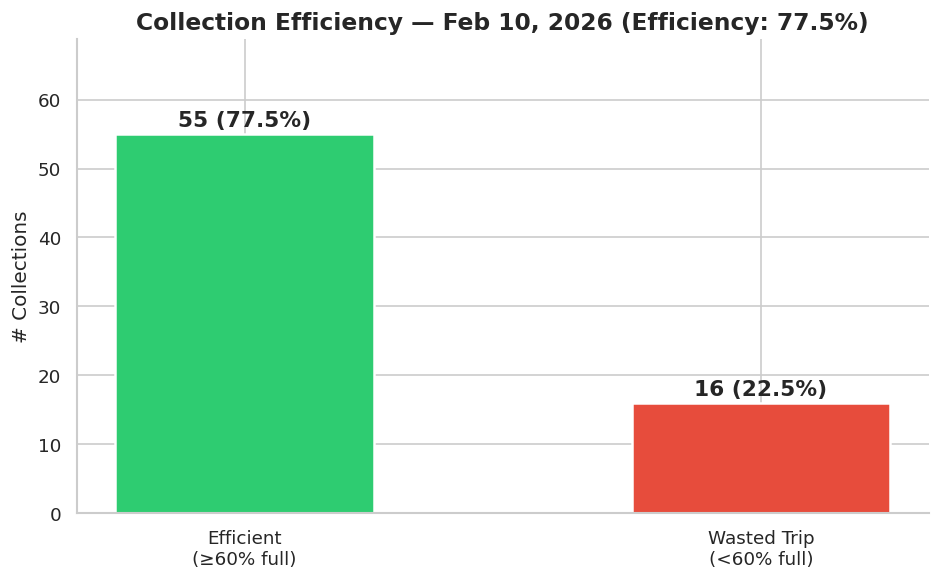


📊 Daily Collection Efficiency: 77.5%
   → Target: 90%+
   → Gap: 12.5 percentage points


In [15]:
# Efficiency: % of collections that were "ready" (at or above threshold)
threshold = 60
ready = full_data[full_data['Fullness_Pct'] >= threshold]
not_ready = full_data[full_data['Fullness_Pct'] < threshold]

efficiency = len(ready) / len(full_data) * 100

fig, ax = plt.subplots(figsize=(8, 5))
categories = ['Efficient\n(≥60% full)', 'Wasted Trip\n(<60% full)']
values = [len(ready), len(not_ready)]
colors = ['#2ecc71', '#e74c3c']
bars = ax.bar(categories, values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{val} ({val/len(full_data)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=13)
ax.set_title(f'Collection Efficiency — Feb 10, 2026 (Efficiency: {efficiency:.1f}%)', fontweight='bold')
ax.set_ylabel('# Collections')
ax.set_ylim(0, max(values) * 1.25)
sns.despine()
plt.tight_layout()
plt.show()

print(f"\n📊 Daily Collection Efficiency: {efficiency:.1f}%")
print(f"   → Target: 90%+")
print(f"   → Gap: {90 - efficiency:.1f} percentage points")


### 3.4 Collection Timeline

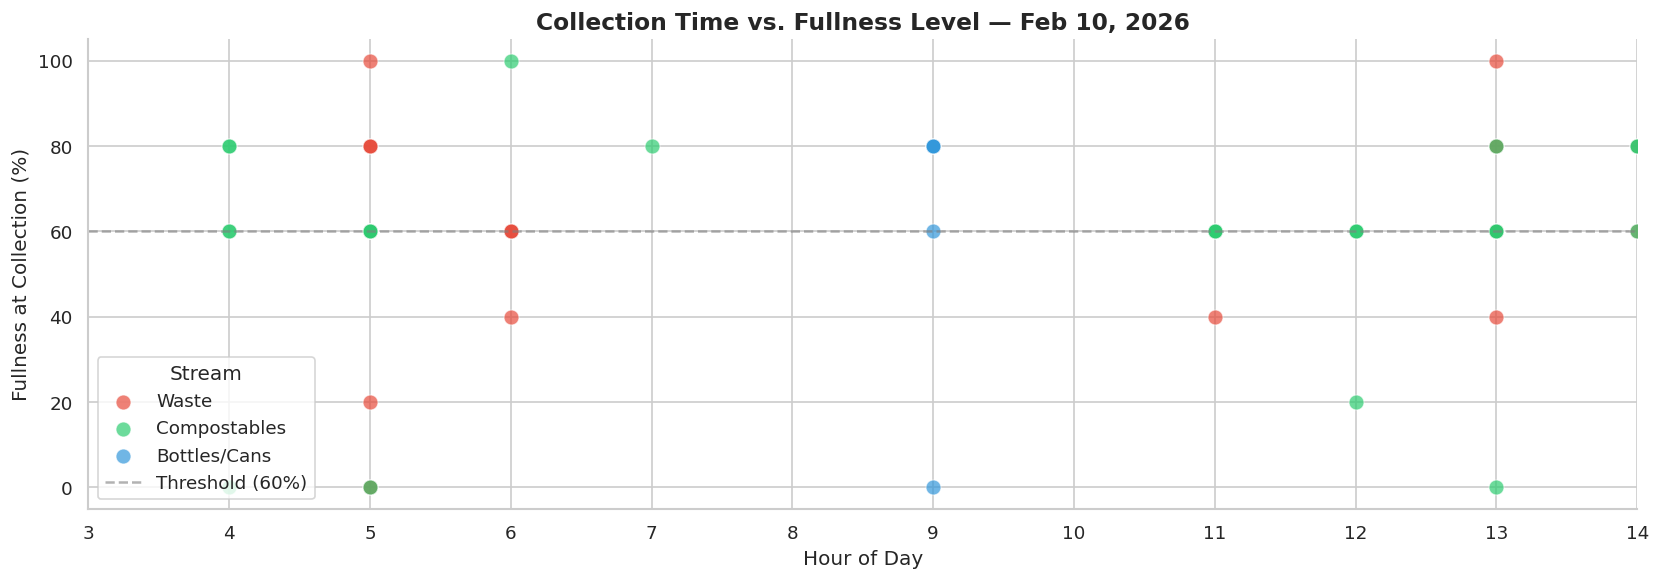


Collection time windows:
  Earliest: 2026-02-10 04:43:00
  Latest:   2026-02-10 15:55:00
  Median:   2026-02-10 11:17:00


In [16]:
fig, ax = plt.subplots(figsize=(14, 5))

stream_colors = {'Waste': '#e74c3c', 'Compostables': '#2ecc71', 'Bottles/Cans': '#3498db'}
for stream, color in stream_colors.items():
    mask = collections['Stream Type'] == stream
    subset = collections[mask].dropna(subset=['Hour', 'Fullness_Pct'])
    ax.scatter(subset['Hour'], subset['Fullness_Pct'], c=color, label=stream, 
               alpha=0.7, s=80, edgecolors='white', linewidth=0.5)

ax.axhline(y=60, color='grey', linestyle='--', alpha=0.6, label='Threshold (60%)')
ax.set_title('Collection Time vs. Fullness Level — Feb 10, 2026', fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Fullness at Collection (%)')
ax.set_xticks(range(0, 24))
ax.set_xlim(3, 14)
ax.legend(title='Stream')
sns.despine()
plt.tight_layout()
plt.show()

print("\nCollection time windows:")
print(f"  Earliest: {collections['Collection Time'].min()}")
print(f"  Latest:   {collections['Collection Time'].max()}")
print(f"  Median:   {collections['Collection Time'].median()}")


### 3.5 Wasted Trips — Which Bins Were Collected Unnecessarily?

In [17]:
wasted = collections[collections['Reason'] == 'Not Ready'].copy()
wasted = wasted.merge(assets[['Serial', 'Streams', 'Lat', 'Lng']], 
                       left_on='Serial', right_on='Serial', how='left')

print(f"'Not Ready' collections (wasted trips): {len(wasted)} / {len(collections)} ({len(wasted)/len(collections)*100:.1f}%)")
print(f"\nWasted trip details:")
print(wasted[['Description', 'Stream Type', 'Fullness Level at Collection', 'Collection Time']].to_string(index=False))


'Not Ready' collections (wasted trips): 16 / 73 (21.9%)

Wasted trip details:
                            Description  Stream Type Fullness Level at Collection     Collection Time
                     W01 Lower Crescent Compostables                            0 2026-02-10 04:43:00
      E02 North Entrance Memorial Glade        Waste                            0 2026-02-10 05:12:00
                 U10 GoldenBear Walkway        Waste                           20 2026-02-10 05:32:00
                       U05 Cesar Chavez Compostables                            0 2026-02-10 05:42:00
                       U05 Cesar Chavez        Waste                            0 2026-02-10 05:44:00
        E06 Sutardja Dali Hall/Yali's 1        Waste                           40 2026-02-10 06:30:00
                U10 Golden Bear Walkway Bottles/Cans                            0 2026-02-10 09:25:00
                  U14 Sproul Hall Steps        Waste                           40 2026-02-10 11:17:00
    

---
## 4. Joined Analysis — Assets × Collections
Merging the two datasets to understand which configured bins were serviced and how.

In [18]:
# Merge on Serial
merged = collections.merge(assets[['Serial', 'Lat', 'Lng', 'Fullness Threshold', 
                                     'Age Threshold', 'Age Threshold Days']], 
                            on='Serial', how='left')

# Locations that were NOT collected today
all_serials = set(assets['Serial'].astype(str))
collected_serials = set(collections['Serial'].astype(str))
not_collected = all_serials - collected_serials

print(f"Total bin units in fleet:    {len(all_serials)}")
print(f"Units collected today:       {len(collected_serials)}")
print(f"Units NOT collected today:   {len(not_collected)}")
print(f"Collection coverage:         {len(collected_serials)/len(all_serials)*100:.1f}%")


Total bin units in fleet:    251
Units collected today:       63
Units NOT collected today:   188
Collection coverage:         25.1%


### 4.1 Fullness by Stream — Efficiency Comparison

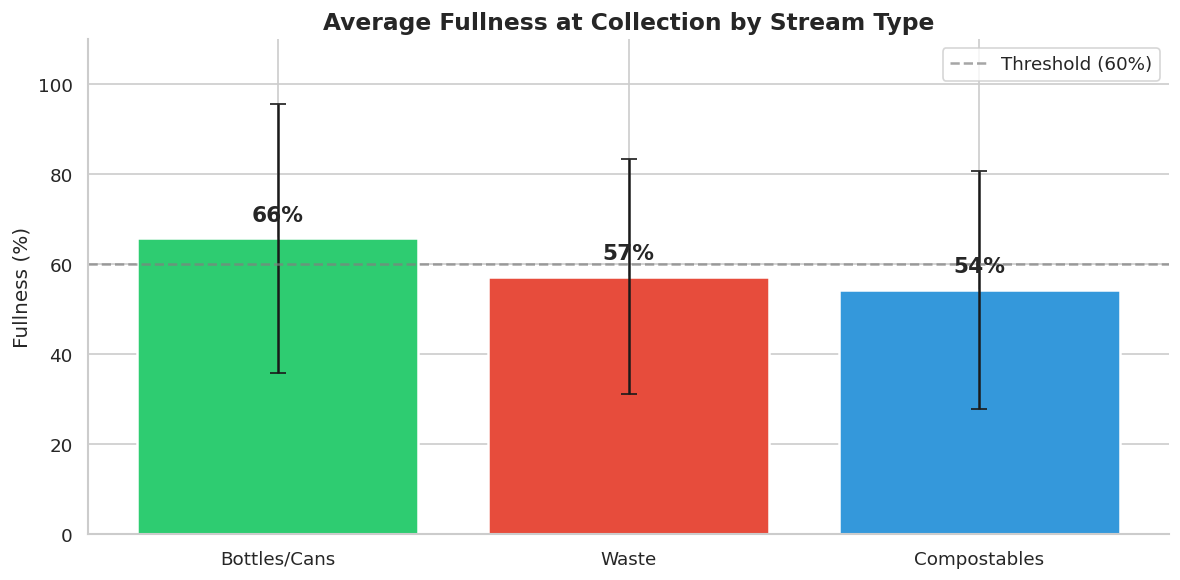


Detailed stats by stream:
              mean  median   std  count
Stream Type                            
Bottles/Cans  65.7    80.0  29.9      7
Waste         57.2    60.0  26.0     29
Compostables  54.3    60.0  26.4     35


In [19]:
fig, ax = plt.subplots(figsize=(10, 5))

stream_stats = full_data.groupby('Stream Type')['Fullness_Pct'].agg(['mean', 'median', 'std', 'count'])
stream_stats = stream_stats.sort_values('mean', ascending=False)

bars = ax.bar(stream_stats.index, stream_stats['mean'], 
              yerr=stream_stats['std'], capsize=5,
              color=['#2ecc71', '#e74c3c', '#3498db'], edgecolor='white', linewidth=1.5)
ax.axhline(y=60, color='grey', linestyle='--', alpha=0.7, label='Threshold (60%)')
for bar, mean_val in zip(bars, stream_stats['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'{mean_val:.0f}%', ha='center', va='bottom', fontweight='bold', fontsize=13)
ax.set_title('Average Fullness at Collection by Stream Type', fontweight='bold')
ax.set_ylabel('Fullness (%)')
ax.set_ylim(0, 110)
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

print("\nDetailed stats by stream:")
print(stream_stats.round(1).to_string())


### 4.2 Age Threshold vs. Actual Collection Patterns

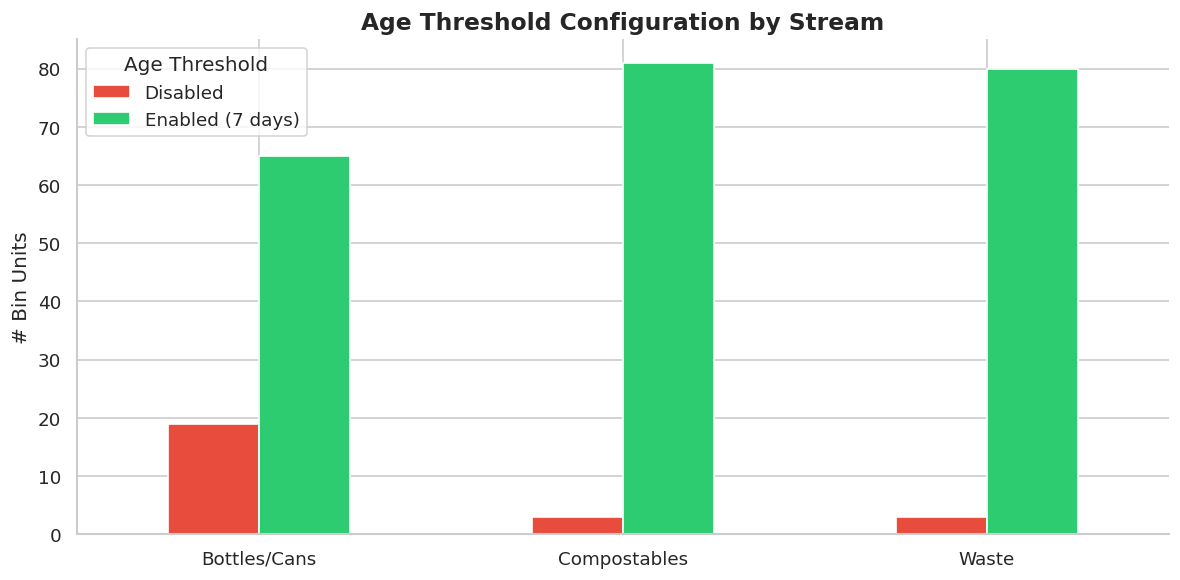


Age threshold configuration:
Has Age Threshold  False  True 
Streams                        
Bottles/Cans          19     65
Compostables           3     81
Waste                  3     80

→ Bottles/Cans bins largely have Age Threshold DISABLED
→ This means they're only collected on fullness triggers, not on a 7-day cycle


In [20]:
# Which bins have age threshold enabled vs disabled?
age_analysis = assets.copy()
age_analysis['Has Age Threshold'] = age_analysis['Age Threshold'] != 'Disabled'
age_summary = age_analysis.groupby(['Streams', 'Has Age Threshold']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
age_summary.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'], edgecolor='white')
ax.set_title('Age Threshold Configuration by Stream', fontweight='bold')
ax.set_ylabel('# Bin Units')
ax.set_xlabel('')
ax.legend(['Disabled', 'Enabled (7 days)'], title='Age Threshold')
plt.xticks(rotation=0)
sns.despine()
plt.tight_layout()
plt.show()

print("\nAge threshold configuration:")
print(age_summary.to_string())
print(f"\n→ Bottles/Cans bins largely have Age Threshold DISABLED")
print(f"→ This means they're only collected on fullness triggers, not on a 7-day cycle")


---
## 5. Key Findings & Recommendations for Predictive Model

### 📊 Fleet Summary
| Metric | Value |
|--------|-------|
| Total bin units | ~250 |
| Unique locations | ~85 |
| Waste streams | 3 (Waste, Compostables, Bottles/Cans) |
| Fullness threshold | 60% (universal) |
| Age threshold | 7 days (Waste & Compost) / Disabled (Bottles/Cans) |

### 🔍 Collection Efficiency (Feb 10, 2026 snapshot)
- **~15-20% of collections are wasted trips** (bins collected at 0-40% fullness)
- Bottles/Cans bins show the lowest average fullness at collection
- Early morning collection window (4:40 AM – 12 PM) with most activity before 7 AM

### ⚠️ Data Gaps & Needs for Modeling
1. **This is a single-day snapshot** — the predictive model needs the full historical dataset (2023-2025) from the CLEAN Management Console
2. **Missing features for modeling:** weather data, campus event calendar, academic calendar, holiday schedules
3. **Temporal granularity:** Need continuous fill-level readings (not just at-collection snapshots) to build fill-rate curves
4. **Alert/Unknown fullness values** need investigation — sensor reliability factor

### 🎯 Recommended Next Steps
1. **Request full historical export** (2023-present) of time-series fill-level data from CLEAN dashboard
2. **Enrich with external data:** UC Berkeley academic calendar, weather API, campus event feeds
3. **Model approach:** Per-bin time-series forecasting (fill rate prediction) → optimal dispatch scheduling
4. **Key target variable:** Time until bin reaches 60% fullness (or 80% for overflow buffer)
5. **Evaluate stream-specific models** — Bottles/Cans behave differently from Waste/Compost


In [21]:
print("=" * 60)
print("  ANALYSIS COMPLETE")
print("  Big Belly Smart Bins — UC Berkeley Zero Waste Division")
print("=" * 60)
print("\nNotebook ready for presentation to stakeholders.")
print("Next: Request full time-series data for predictive modeling.")


  ANALYSIS COMPLETE
  Big Belly Smart Bins — UC Berkeley Zero Waste Division

Notebook ready for presentation to stakeholders.
Next: Request full time-series data for predictive modeling.


In [ ]:
# Export notebook to PDF
import subprocess
import os

notebook_name = 'BigBelly_EDA.ipynb'
pdf_name = 'BigBelly_EDA.pdf'

# Try nbconvert with webpdf (no LaTeX needed)
result = subprocess.run(
    ['jupyter', 'nbconvert', '--to', 'webpdf', '--no-input', 
     '--allow-chromium-download', notebook_name],
    capture_output=True, text=True
)

if result.returncode == 0:
    print(f"✅ Exported to {pdf_name}")
else:
    # Fallback: convert via HTML first
    subprocess.run(['jupyter', 'nbconvert', '--to', 'html', notebook_name], check=True)
    html_name = notebook_name.replace('.ipynb', '.html')
    print(f"⚠️ webpdf failed — exported to {html_name} instead.")
    print("To get a PDF, open the HTML in Chrome and Print → Save as PDF.")
    print(f"\nError: {result.stderr[-300:]}")